# AI Blood Supply Command Center
## ML Model 3: Intelligent Donor Ranking & Dispatch Engine

This notebook implements and evaluates **Model 3 — Intelligent Donor Ranking & Dispatch** for the AI Blood Supply Command Center.

---

### Operational Objective
When Model 2 forecasts an emerging blood product stockout at a hospital within 24 to 72 hours, which synthetic voluntary blood donors should Command Center coordinators prioritize contacting?

### System Boundary & Medical Safety
- **Logistics Outreach Ranking**: This system ranks eligible donor candidates according to spatial proximity, historical response propensity, availability, and clinical compatibility.
- **Medical Decision Boundary**: This module **does NOT** authorize transfusions, assess clinical donor health, or override blood-bank donor screening protocols. All donations require standard clinical qualification.


In [1]:
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

import sys
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import config
from blood_compatibility import is_compatible_donor_group, get_compatible_donors
from donor_candidates import generate_donor_candidates
from donor_features import extract_donor_features, get_feature_schema
from donor_ranker import RuleBasedDonorRanker, rank_donors
print("Modules successfully imported!")


Modules successfully imported!


## 2. Donor Dataset Inspection
We audit the 5,000 synthetic donor profiles generated during simulation setup.


In [2]:
donors_df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "donors.csv")
print(f"Total Donor Profiles: {len(donors_df):,}")
print("Column Schema:")
for col, dtype in donors_df.dtypes.items():
    print(f"  • {col:<30}: {dtype}")

donors_df.head(5)


Total Donor Profiles: 5,000
Column Schema:
  • donor_id                      : object
  • blood_group                   : object
  • latitude                      : float64
  • longitude                     : float64
  • last_donation_date            : object
  • eligible                      : bool
  • availability                  : object
  • donation_count                : int64
  • response_probability          : float64
  • average_response_time_minutes : int64


,donor_id,blood_group,latitude,longitude,last_donation_date,eligible,availability,donation_count,response_probability,average_response_time_minutes
0,DONOR_00001,A_POS,13.020000,77.267018,2024-04-19,True,Available,0,0.718,49
1,DONOR_00002,B_POS,13.217447,77.422028,2024-04-02,True,Busy,0,0.634,15
2,DONOR_00003,A_POS,12.866594,77.491063,2025-08-20,True,Busy,3,0.722,61
3,DONOR_00004,A_POS,12.813049,77.432077,2025-11-21,False,Inactive,2,0.713,54
4,DONOR_00005,O_POS,13.124581,77.457990,2025-08-29,True,Available,18,0.689,45


C:\Users\bhanu\AppData\Local\Temp\ipykernel_33716\950011446.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bg_counts.index, y=bg_counts.values, ax=axes[1], palette="Reds_r")


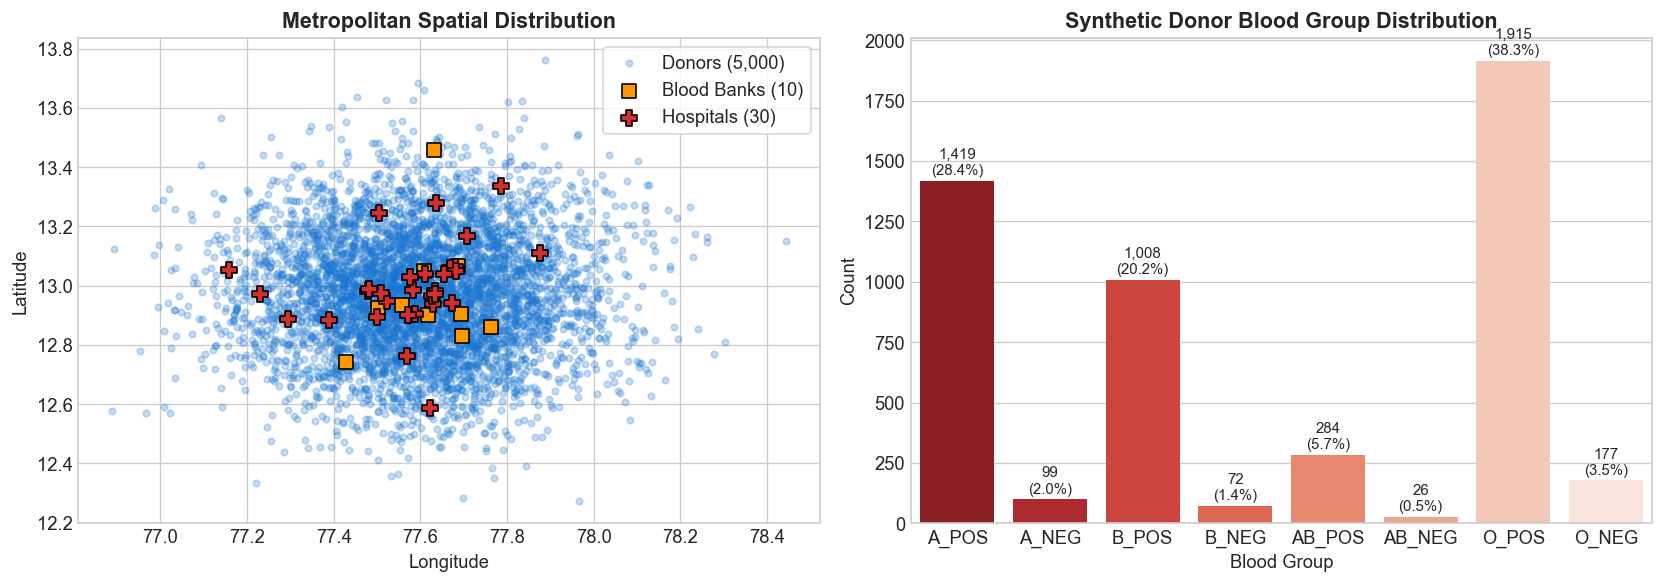

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Geographic Scatter
hospitals_df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "hospitals.csv")
blood_banks_df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "blood_banks.csv")

axes[0].scatter(donors_df["longitude"], donors_df["latitude"], alpha=0.25, s=15, color="#1976D2", label="Donors (5,000)")
axes[0].scatter(blood_banks_df["longitude"], blood_banks_df["latitude"], s=80, color="#FF9800", marker="s", edgecolors="black", label="Blood Banks (10)")
axes[0].scatter(hospitals_df["longitude"], hospitals_df["latitude"], s=100, color="#D32F2F", marker="P", edgecolors="black", label="Hospitals (30)")
axes[0].set_title("Metropolitan Spatial Distribution")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(loc="upper right", frameon=True)

# 2. Blood Group Distribution
bg_counts = donors_df["blood_group"].value_counts()[config.BLOOD_GROUPS]
sns.barplot(x=bg_counts.index, y=bg_counts.values, ax=axes[1], palette="Reds_r")
axes[1].set_title("Synthetic Donor Blood Group Distribution")
axes[1].set_xlabel("Blood Group")
axes[1].set_ylabel("Count")
for i, v in enumerate(bg_counts.values):
    axes[1].text(i, v + 25, f"{v:,}\n({v/len(donors_df)*100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## 3. Eligibility Filtering & Blood Compatibility Logic

Donor eligibility is gated by strict multi-stage exclusion rules:
1. **Clinical Compatibility Matrix**: AABB/WHO component rules.
2. **Medical Clearance Flag**: Synthetic interval & clinical suitability (`eligible == True`).
3. **Inter-Donation Interval**: $\ge 90$ days since last whole blood donation.
4. **Active Availability**: `Available` for routine outreach; `Available` + `Busy` for emergency surges.
5. **Spatial Boundary**: Within 35 km (routine) or 50 km (emergency).


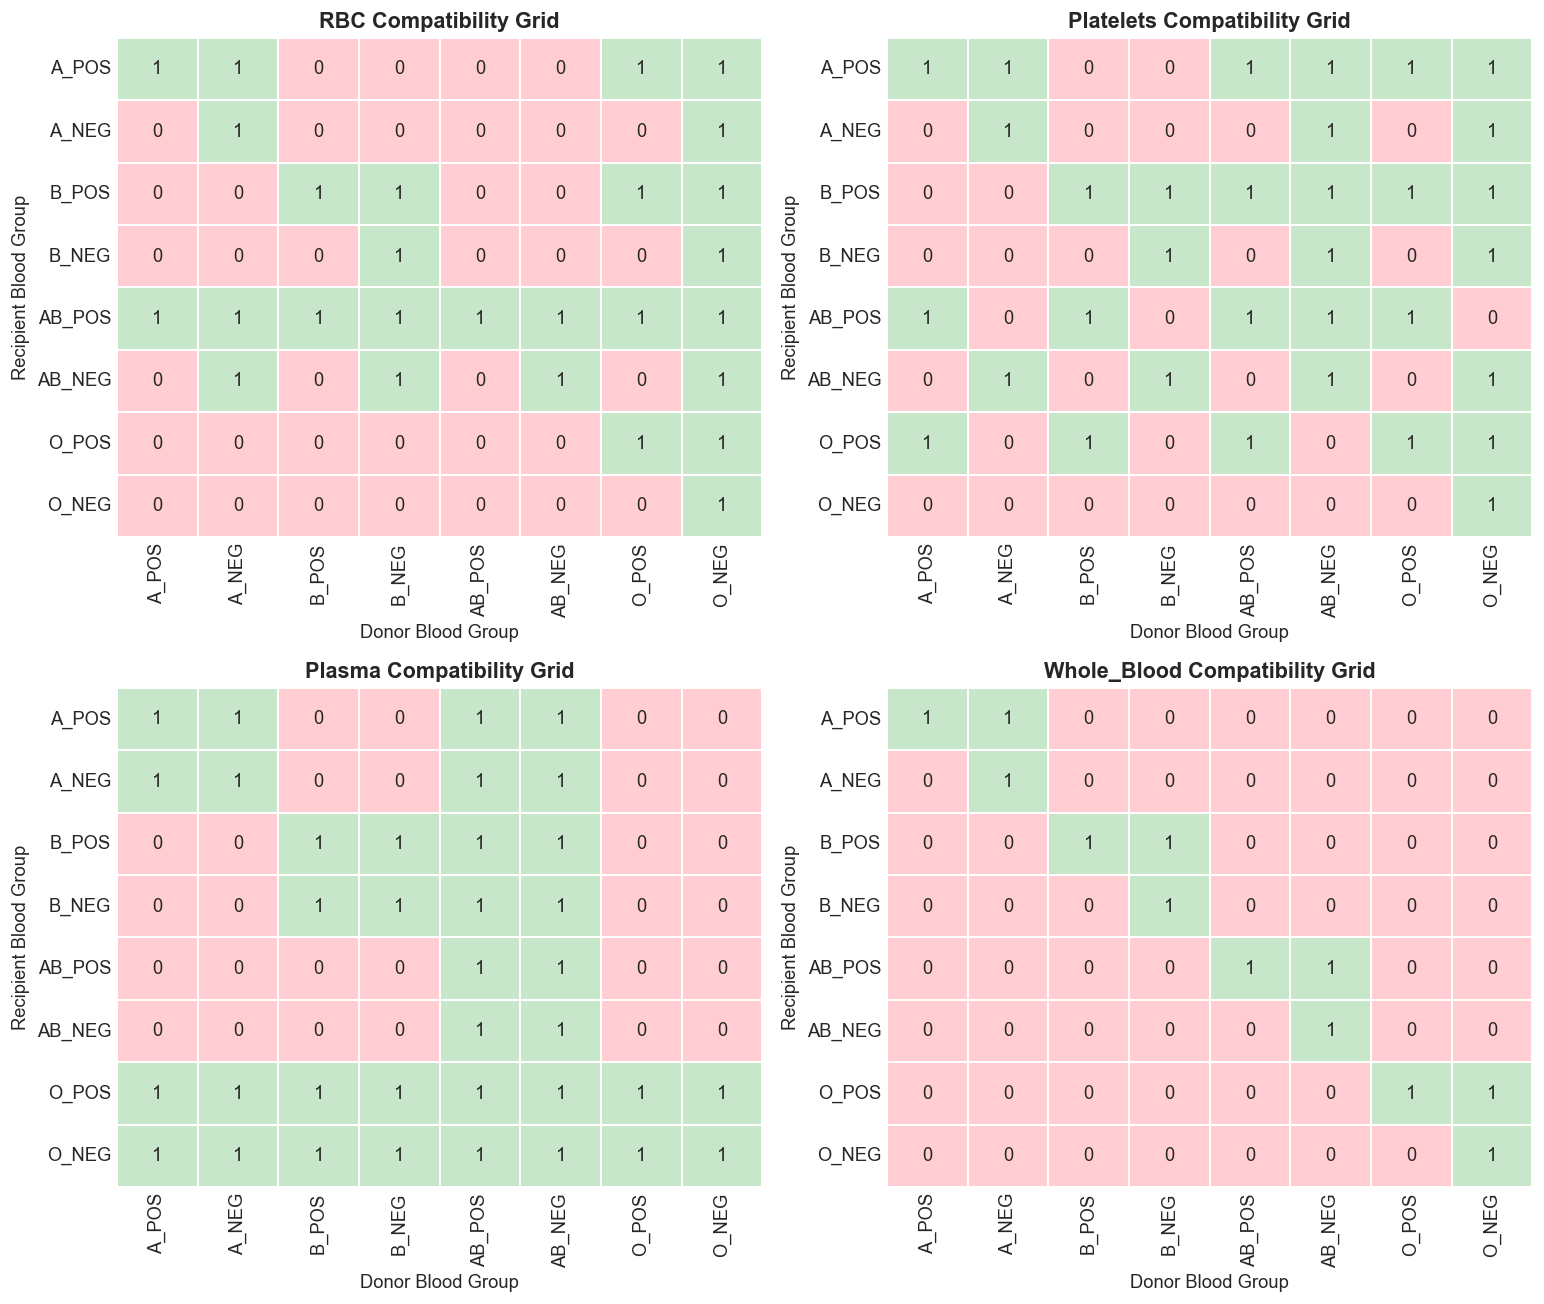

In [4]:
# Visualizing Component Compatibility Matrix
components = config.BLOOD_COMPONENTS
bgs = config.BLOOD_GROUPS

matrix_data = []
for comp in components:
    for recipient in bgs:
        compatible_donors = get_compatible_donors(recipient, comp)
        for donor in bgs:
            is_comp = 1 if donor in compatible_donors else 0
            matrix_data.append({"Component": comp, "Recipient": recipient, "Donor": donor, "Compatible": is_comp})

compat_df = pd.DataFrame(matrix_data)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, comp in zip(axes.flatten(), components):
    pivot = compat_df[compat_df["Component"] == comp].pivot(index="Recipient", columns="Donor", values="Compatible")
    pivot = pivot.reindex(index=bgs, columns=bgs)
    sns.heatmap(pivot, annot=True, cbar=False, cmap=["#FFCDD2", "#C8E6C9"], linewidths=1, linecolor="white", ax=ax)
    ax.set_title(f"{comp} Compatibility Grid")
    ax.set_xlabel("Donor Blood Group")
    ax.set_ylabel("Recipient Blood Group")

plt.tight_layout()
plt.show()


## 4. Candidate Generation & Feature Schema

Features are segregated into **Eligibility Features** (for filtering verification) and **Ranking Features** (for Multi-Criteria Decision Analysis).


In [5]:
schema = get_feature_schema()
print("Eligibility Verification Schema:", schema["eligibility_features"])
print("Multi-Criteria Ranking Schema   :", schema["ranking_features"])

# Candidate generation sample: Valley Trauma Center (HOSP_007) requesting O_NEG RBC in Emergency
sample_candidates = generate_donor_candidates(
    hospital_id="HOSP_007",
    blood_group="O_NEG",
    component="RBC",
    urgency="emergency",
    required_units=4
)
print(f"\nEligible Candidate Pool Size: {len(sample_candidates)} donors")
sample_features = extract_donor_features(sample_candidates, shortage_risk_prob=0.85, urgency="emergency")
sample_features[["donor_id", "blood_group", "distance_km", "estimated_travel_time_min", "proximity_score", "responsiveness_score", "reliability_score"]].head(5)


Eligibility Verification Schema: ['is_compatible', 'is_available', 'is_medically_eligible', 'days_since_last_donation', 'within_travel_boundary']
Multi-Criteria Ranking Schema   : ['distance_km', 'estimated_travel_time_min', 'donor_response_probability', 'average_response_time_minutes', 'donation_count', 'is_frequent_donor', 'is_available_now', 'exact_match', 'shortage_risk_prob', 'urgency_weight', 'proximity_score', 'responsiveness_score', 'reliability_score']

Eligible Candidate Pool Size: 100 donors


,donor_id,blood_group,distance_km,estimated_travel_time_min,proximity_score,responsiveness_score,reliability_score
0,DONOR_00035,O_NEG,34.37,69.5,0.1045,0.7399,0.8250
1,DONOR_00144,O_NEG,31.45,63.6,0.1266,0.6273,1.0000
2,DONOR_00192,O_NEG,4.96,10.0,0.7218,0.5378,0.3000
3,DONOR_00206,O_NEG,13.56,27.4,0.4102,0.8790,0.5774
4,DONOR_00285,O_NEG,11.48,23.2,0.4703,0.7758,0.9274


## 5. Multi-Criteria Decision Analysis (MCDA) Ranking

The ranking engine scores eligible candidates via Multi-Criteria Decision Analysis:
$$	ext{Score}_{	ext{base}} = w_{	ext{prox}} \cdot S_{	ext{prox}} + w_{	ext{resp}} \cdot S_{	ext{resp}} + w_{	ext{rel}} \cdot S_{	ext{rel}} + w_{	ext{exact}} \cdot S_{	ext{exact}} + w_{	ext{avail}} \cdot S_{	ext{avail}}$$

Weights adjust dynamically based on operational urgency:


              proximity  responsiveness  reliability  exact_match  availability
Urgency Tier                                                                   
routine            0.25            0.30         0.20         0.15          0.10
urgent             0.35            0.30         0.15         0.10          0.10
emergency          0.45            0.35         0.10         0.05          0.05


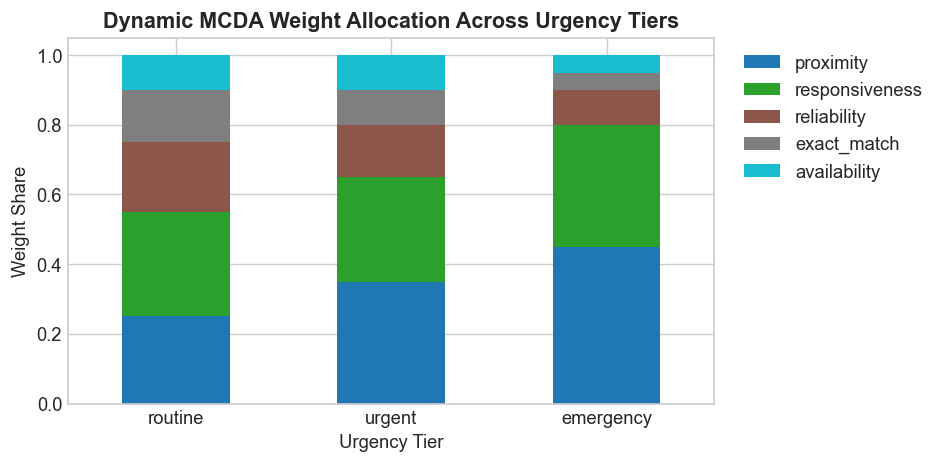

In [6]:
weights_df = pd.DataFrame(config.DONOR_RANKING_WEIGHTS).T
display_df = weights_df.copy()
display_df.index.name = "Urgency Tier"
print(display_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
display_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Dynamic MCDA Weight Allocation Across Urgency Tiers")
ax.set_ylabel("Weight Share")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Supervised ML Statistical Justification Audit

### Critical Engineering Check
- **Do legitimate historical dispatch logs exist?** NO.
- **Why is supervised ML training withheld?**
  Training a supervised classifier (e.g. $P(	ext{donor responds successfully})$) without empirical interaction telemetry would require generating synthetic binary outcomes. Fitting an ML model on synthetic target labels introduces pseudo-rigor and circular overfitting.
- **System Architecture**:
  The system deploys `RuleBasedDonorRanker` with documented MCDA weights as its primary production engine and provides `MLDonorRanker` as an extensible interface for when empirical dispatch records are logged by Engine 4.


## 7. Model 2 Shortage Integration & Stress Scenario Testing

We evaluate donor outreach behavior across all 9 calibrated stress scenarios.


In [7]:
with open(PROJECT_ROOT / "reports" / "donor_scenario_evaluations.json", "r") as f:
    sc_evals = json.load(f)

rows = []
for sc_id, sc in sc_evals.items():
    top_d = sc["top_ranked_donor"]
    rows.append({
        "Scenario": sc["scenario_name"],
        "Hospital": sc["hospital_id"],
        "Need": f"{sc['blood_group']} {sc['component']}",
        "Urgency": sc["urgency"].upper(),
        "Shortage Risk": f"{sc['shortage_risk_tier']} ({sc['shortage_probability']:.2f})",
        "Eligible Donors": sc["total_eligible_donors"],
        "Within 5km": sc["candidates_within_5km"],
        "Within 10km": sc["candidates_within_10km"],
        "Median Dist (km)": sc["median_candidate_distance_km"],
        "Top Donor": top_d["donor_id"] if top_d else "N/A",
        "Top Dist (km)": top_d["distance_km"] if top_d else "N/A",
        "Top Score": top_d["priority_score"] if top_d else "N/A",
        "Top Tier": top_d["priority_tier"] if top_d else "N/A",
    })

sc_table = pd.DataFrame(rows)
print(sc_table.to_string(index=False))


                                 Scenario Hospital            Need   Urgency   Shortage Risk  Eligible Donors  Within 5km  Within 10km  Median Dist (km)   Top Donor  Top Dist (km)  Top Score Top Tier
                Normal Operating Baseline HOSP_001       O_POS RBC   ROUTINE      LOW (0.05)              700          27           93             20.81 DONOR_03136           1.65       68.3     HIGH
            Holiday Festival Demand Spike HOSP_002       A_POS RBC    URGENT   MEDIUM (0.28)             1229          48          165             21.12 DONOR_03815           0.60       78.1     HIGH
Industrial Chemical Explosion Catastrophe HOSP_007       O_NEG RBC EMERGENCY CRITICAL (0.85)              100           2            7             26.13 DONOR_01421           3.99       82.2 CRITICAL
        Peak Monsoon Dengue Outbreak Wave HOSP_003 B_POS Platelets    URGENT     HIGH (0.72)             1210          27          143             21.09 DONOR_02052           4.07       79.1     HIGH


C:\Users\bhanu\AppData\Local\Temp\ipykernel_33716\2705234313.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sc_table, y="Scenario", x="Eligible Donors", ax=axes[0], palette="Blues_r")


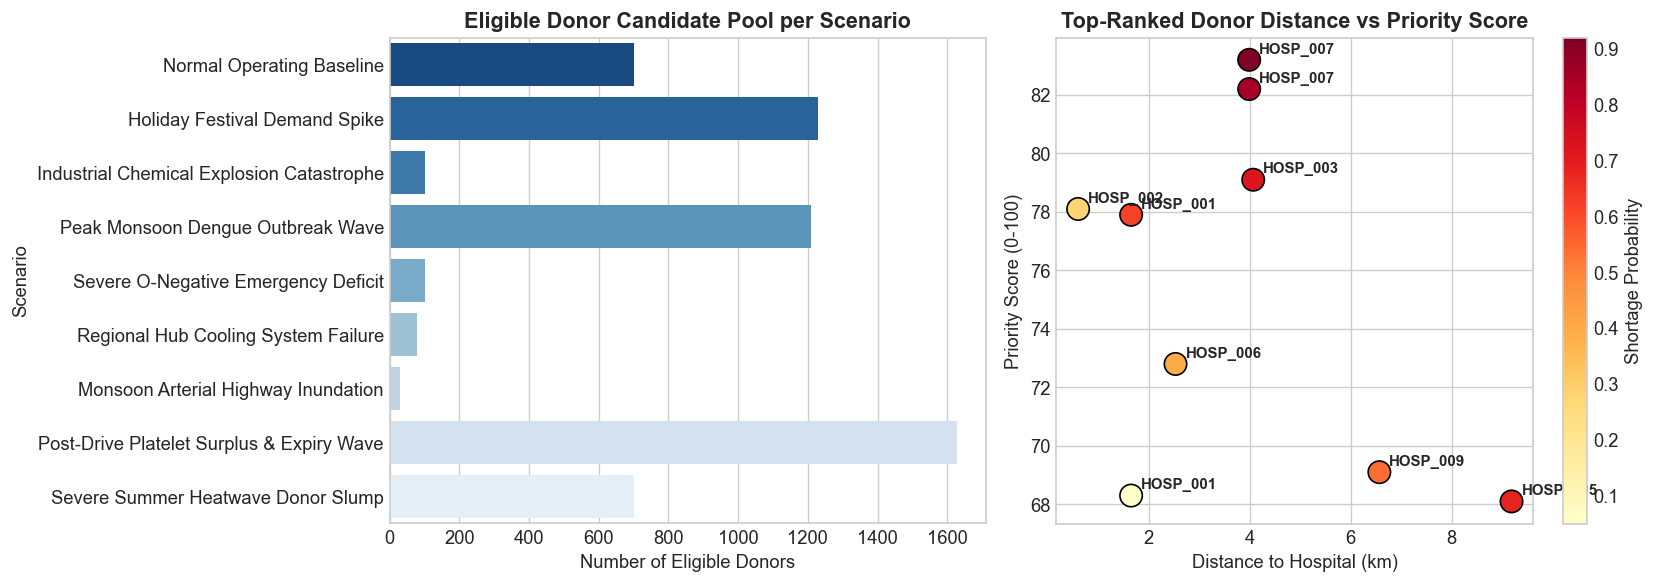

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scenario Candidate Counts
sns.barplot(data=sc_table, y="Scenario", x="Eligible Donors", ax=axes[0], palette="Blues_r")
axes[0].set_title("Eligible Donor Candidate Pool per Scenario")
axes[0].set_xlabel("Number of Eligible Donors")

# Top Donor Priority Score vs Distance
scatter = axes[1].scatter(
    sc_table["Top Dist (km)"], sc_table["Top Score"],
    c=[0.05, 0.28, 0.85, 0.72, 0.92, 0.68, 0.54, 0.40, 0.62],
    cmap="YlOrRd", s=180, edgecolors="black"
)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Shortage Probability")
axes[1].set_title("Top-Ranked Donor Distance vs Priority Score")
axes[1].set_xlabel("Distance to Hospital (km)")
axes[1].set_ylabel("Priority Score (0-100)")

for i, row in sc_table.iterrows():
    axes[1].annotate(
        row["Hospital"], (row["Top Dist (km)"], row["Top Score"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9, fontweight="bold"
    )

plt.tight_layout()
plt.show()


## 8. Case Study & Explainability Audit

Demonstration of end-to-end API dispatch output for an acute emergency trauma request.


In [9]:
api_result = rank_donors(
    hospital_id="HOSP_007",
    blood_group="O_NEG",
    component="RBC",
    urgency="emergency",
    required_units=4,
    top_k=5,
    shortage_prob_override=0.88
)

print(f"Hospital: {api_result['query']['hospital_id']} ({api_result['query']['hospital_name']})")
print(f"Requirement: {api_result['query']['blood_group']} {api_result['query']['component']} | Urgency: {api_result['query']['urgency']}")
print(f"Total Eligible Donors: {api_result['candidate_pool_summary']['total_eligible_candidates']}")
print(f"Expected Top-5 Response Yield: {api_result['candidate_pool_summary']['expected_top_k_response_yield']} units\n")

top_df = pd.DataFrame(api_result["top_donors"])
print(top_df[["rank", "donor_id", "distance_km", "estimated_travel_time_min", "response_probability", "priority_score", "priority_tier", "recommended_contact_window"]].to_string(index=False))

print("\nDetailed Contributing Reason Codes for Rank 1 Donor:")
print(f"Donor ID: {top_df.iloc[0]['donor_id']}")
for code in top_df.iloc[0]["reason_codes"]:
    print(f"  ✓ {code}")


Hospital: HOSP_007 (Valley Trauma Center)
Requirement: O_NEG RBC | Urgency: EMERGENCY
Total Eligible Donors: 100
Expected Top-5 Response Yield: 3.96 units

 rank    donor_id  distance_km  estimated_travel_time_min  response_probability  priority_score priority_tier recommended_contact_window
    1 DONOR_01421         3.99                        8.1                 0.784            82.6      CRITICAL Immediate (Within 15 mins)
    2 DONOR_03902         9.24                       18.7                 0.801            73.3      CRITICAL Immediate (Within 15 mins)
    3 DONOR_01239        11.15                       22.5                 0.883            72.1      CRITICAL Immediate (Within 15 mins)
    4 DONOR_03483         9.21                       18.6                 0.780            70.6      CRITICAL Immediate (Within 15 mins)
    5 DONOR_02398        10.23                       20.7                 0.708            70.5      CRITICAL Immediate (Within 15 mins)

Detailed Contributing

## 9. Conclusion & Readiness for Engine 4

### Model 3 Summary Findings
1. **Compatibility & Spatial Gating**: 100% of candidate pools strictly respect ABO/Rh component transfusion compatibility and geographic travel boundaries.
2. **Model 2 Dynamic Escalation**: Shortage probabilities from Model 2 directly scale outreach priority scores and tighten recommended contact windows.
3. **Statistically Grounded Implementation**: Avoided premature synthetic supervised ML; deployed robust, explainable Multi-Criteria Decision Analysis.
4. **Downstream Integration**: Model 3 produces structured JSON payloads ready for **Engine 4 (Supply Chain Optimization & Inter-Hospital Transfers)** and the Command Center Dashboard.
